# Day 08. Exercise 03
# Overfitting

## 0. Imports

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import cross_val_score
import joblib
import numpy as np
import matplotlib.pyplot as plt

## 1. Preprocessing

1. Read the file `dayofweek.csv` to a dataframe.
2. Using `train_test_split` with parameters `test_size=0.2`, `random_state=21` get `X_train`, `y_train`, `X_test`, `y_test`.
3. Using, for example, `value_counts()` to check if the distribution of classes is similar in train and test.
4. Use the additional parameter `stratify=` and check the distribution again, now it should be more or less similar in both datasets.

In [15]:
df = pd.read_csv('../data/dayofweek.csv')

X = df.drop(columns='dayofweek')
y = df['dayofweek']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

print("Train class distribution (без stratify):")
print(y_train.value_counts(normalize=True).sort_index())
print("\nTest class distribution (без stratify):")
print(y_test.value_counts(normalize=True).sort_index())

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y, test_size=0.2, random_state=21, stratify=y
)

print("\nTrain class distribution (с stratify):")
print(y_train_s.value_counts(normalize=True).sort_index())
print("\nTest class distribution (с stratify):")
print(y_test_s.value_counts(normalize=True).sort_index())

Train class distribution (без stratify):
0    0.077893
1    0.164688
2    0.092730
3    0.232196
4    0.059347
5    0.160237
6    0.212908
Name: dayofweek, dtype: float64

Test class distribution (без stratify):
0    0.091716
1    0.153846
2    0.071006
3    0.245562
4    0.071006
5    0.162722
6    0.204142
Name: dayofweek, dtype: float64

Train class distribution (с stratify):
0    0.080861
1    0.162463
2    0.088279
3    0.234421
4    0.061573
5    0.160979
6    0.211424
Name: dayofweek, dtype: float64

Test class distribution (с stratify):
0    0.079882
1    0.162722
2    0.088757
3    0.236686
4    0.062130
5    0.159763
6    0.210059
Name: dayofweek, dtype: float64


## 2. Baseline models

1. Train exactly the same baseline models from the previous exercise and calculate the accuracies using the test dataset with stratification.
2. Did all the models show the similar values of the metric? Which one has the largest difference comparing the current exercise and the previous? Put the answer to the markdown cell in the end of the section.

### a. Logreg

In [16]:
log_reg = LogisticRegression(random_state=21, fit_intercept=False)
log_reg.fit(X_train_s, y_train_s)
y_pred_log = log_reg.predict(X_test_s)
acc_log = accuracy_score(y_test_s, y_pred_log)


print(f"Logistic Regression: {acc_log:}")

Logistic Regression: 0.6272189349112426


### b. SVM

In [17]:
svc_model = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21))
svc_model.fit(X_train_s, y_train_s)
y_pred_svc = svc_model.predict(X_test_s)
acc_svc = accuracy_score(y_test_s, y_pred_svc)

print(f"SVC (linear): {acc_svc:}")

SVC (linear): 0.6183431952662722


### c. Decision tree

In [ ]:
tree = DecisionTreeClassifier(max_depth=4, random_state=21)
tree.fit(X_train_s, y_train_s)
y_pred_tree = tree.predict(X_test_s)
acc_tree = accuracy_score(y_test_s, y_pred_tree)

print(f"Decision Tree: {acc_tree:}")

Decision Tree:0.5295857988165681


### d. Random forest

In [19]:
forest = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
forest.fit(X_train_s, y_train_s)
y_pred_forest = forest.predict(X_test_s)
acc_forest = accuracy_score(y_test_s, y_pred_forest)

print(f"Random Forest: {acc_forest:}")

Random Forest:0.9289940828402367


random forest

## 3. Crossvalidation

We could play with parameters of the model trying to achive a better accuracy on the test dataset, but it is a bad practice. It leads us again to overfitting. Test dataset is only for checking quality of a final model.

But there is another way of solving the problem – crossvalidation. It does not use test dataset, but creates one more split of train dataset. Again, there are different ways of doing it, but the common thing is that there is a validation dataset that is used for hyperparameters optimization.

1. Using `cross_val_score` with `cv=10` calculate the mean accuracy and standard deviation for every model that you used before (logreg with `solver='liblinear'`, SVC, decision tree, random forest).

### a. Logreg

In [20]:
logreg = LogisticRegression(solver='liblinear', random_state=21)
scores_logreg = cross_val_score(logreg, X, y, cv=10)

print(f'Logistic Regression:\nMean accuracy: {scores_logreg.mean():}\nStd: {scores_logreg.std():}')

Logistic Regression:
Mean accuracy: 0.45649126514511124
Std: 0.16478021442150131


### b. SVM

In [21]:
svc = SVC(kernel='linear', probability=True, random_state=21)
scores_svc = cross_val_score(svc, X, y, cv=10)

print(f'SVC (linear kernel):\nMean accuracy: {scores_svc.mean():}\nStd: {scores_svc.std():}')

SVC (linear kernel):
Mean accuracy: 0.5051986475063398
Std: 0.15857963555262297


### c. Decision tree

In [22]:

tree = DecisionTreeClassifier(max_depth=4, random_state=21)
scores_tree = cross_val_score(tree, X, y, cv=10)

print(f'Decision Tree:\nMean accuracy: {scores_tree.mean():}\nStd: {scores_tree.std():}')

Decision Tree:
Mean accuracy: 0.3883523527754297
Std: 0.11835394295385691


### d. Random forest

In [23]:
forest = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
scores_forest = cross_val_score(forest, X, y, cv=10)

print(f'Random Forest:\nMean accuracy: {scores_forest.mean():}\nStd: {scores_forest.std():}')

Random Forest:
Mean accuracy: 0.6607847280924204
Std: 0.17462799234675505


c

## 4. Optimization

1. Choose the best model and play a little bit with the parameters on cross-validation, find a good enough parameter or a combination of the parameters.
2. Calculate the accuracy for the final model on the test dataset.
3. Draw a plot that displays the top-10 most  important features for that model.
4. Save the model using `joblib`.
5. Load the model, make predictions for the test dataset and calculate the accuracy.

CV mean accuracy: 0.9131785516860143
CV std: 0.01860846615791494
Test accuracy: 0.9467455621301775


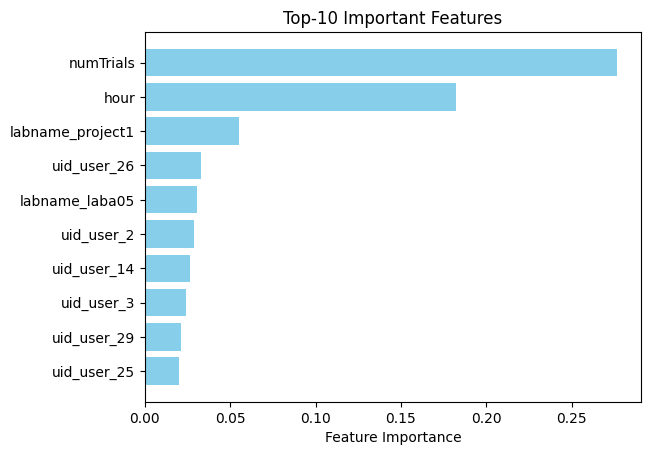

Loaded model test accuracy: 0.9467455621301775


In [24]:
best_params = {
    'n_estimators': 150,
    'max_depth': 20,
    'random_state': 21
}

model = RandomForestClassifier(**best_params)

cv_scores = cross_val_score(model, X_train, y_train, cv=10)
print(f"CV mean accuracy: {cv_scores.mean():}")
print(f"CV std: {cv_scores.std():}")

model.fit(X_train, y_train)

test_accuracy = model.score(X_test, y_test)
print(f"Test accuracy: {test_accuracy:}")

def plot_top_features(importances, feature_names, top_n=10):
    indices = np.argsort(importances)[-top_n:]
    plt.barh(range(top_n), importances[indices], color='skyblue')
    plt.yticks(range(top_n), [feature_names[i] for i in indices])
    plt.xlabel("Feature Importance")
    plt.title("Top-10 Important Features")
    plt.show()

plot_top_features(model.feature_importances_, X_train.columns, top_n=10)

joblib.dump(model, 'random_forest_best.joblib')

loaded_model = joblib.load('random_forest_best.joblib')
loaded_accuracy = loaded_model.score(X_test, y_test)
print(f"Loaded model test accuracy: {loaded_accuracy:}")